## The dataset contains 
48,895 Airbnb listings across New York City's 5 boroughs (2019), covering location, price, room type, host, and review activity. After cleaning (dropped 10,052 rows missing last_review, removed price outliers via IQR), the working dataset has 36,766 rows across 13 columns. Manhattan and Brooklyn dominate the listings (85% combined) and command the highest prices, while price shows no meaningful correlation with reviews, availability, or minimum nights — location and room type are the real price drivers.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

In [2]:
df = pd.read_csv("../data/AB_NYC_2019.csv")
df.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365


#### Check Null values

In [3]:
round(df.isnull().sum()/len(df)*100,2).sort_values(ascending=False)

last_review                       20.56
reviews_per_month                 20.56
host_name                          0.04
name                               0.03
neighbourhood_group                0.00
neighbourhood                      0.00
id                                 0.00
host_id                            0.00
longitude                          0.00
latitude                           0.00
room_type                          0.00
price                              0.00
number_of_reviews                  0.00
minimum_nights                     0.00
calculated_host_listings_count     0.00
availability_365                   0.00
dtype: float64

In [4]:
df.groupby(df["last_review"].isnull())["reviews_per_month"].mean()

last_review
False    1.373221
True          NaN
Name: reviews_per_month, dtype: float64

#### Drop values of last review because it contain 20% more null

In [5]:
df.dropna(subset=["last_review"], inplace=True)

In [6]:
df.isnull().sum()

id                                 0
name                               6
host_id                            0
host_name                         16
neighbourhood_group                0
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
last_review                        0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
dtype: int64

#### Adding unknown to null value of host name

In [7]:
df["host_name"].fillna("unknown",inplace= True)

/tmp/ipykernel_600/2251233054.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["host_name"].fillna("unknown",inplace= True)


0               John
1           Jennifer
3        LisaRoxanne
4              Laura
5              Chris
            ...     
48782          Rusaa
48790           H Ai
48799            Ben
48805         Blaine
48852      Christine
Name: host_name, Length: 38843, dtype: str

#### Checking box plot to check how data is distributed and how much outliers are there

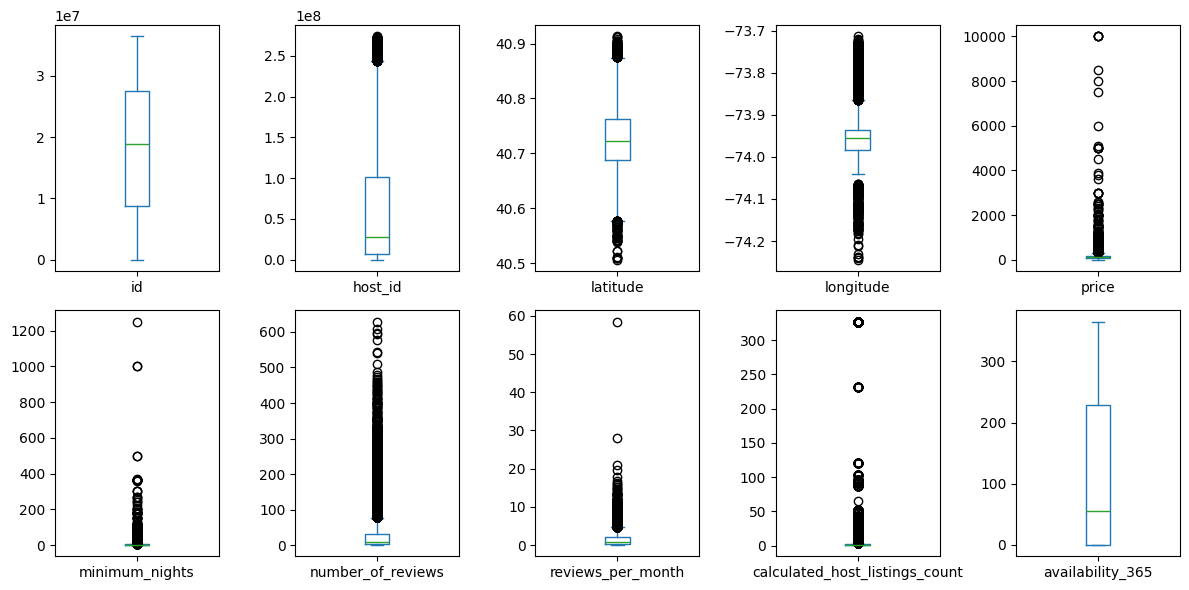

In [8]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].plot(kind="box", subplots=True, layout=(2, -1), figsize=(12, 6))
plt.tight_layout()
plt.show()

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 38843 entries, 0 to 48852
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              38843 non-null  int64  
 1   name                            38837 non-null  str    
 2   host_id                         38843 non-null  int64  
 3   host_name                       38827 non-null  str    
 4   neighbourhood_group             38843 non-null  str    
 5   neighbourhood                   38843 non-null  str    
 6   latitude                        38843 non-null  float64
 7   longitude                       38843 non-null  float64
 8   room_type                       38843 non-null  str    
 9   price                           38843 non-null  int64  
 10  minimum_nights                  38843 non-null  int64  
 11  number_of_reviews               38843 non-null  int64  
 12  last_review                     38843 non-null  

#### Making Outlier removing function

In [10]:
def outlier_remover(df,col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1 
    MIN = Q1 - IQR*1.5
    MAX = Q3 + IQR*1.5
    mask= (df[col] > MIN) & (df[col]  < MAX)
    return df[mask]

##### Drop some unneccary coloumns which dont have any mean

In [11]:
df.drop(columns=["id","host_id","name","host_name"],inplace=True)

#### Before removing outliers check it distribution of price coloumn and z score values
#### As price z_score value if more than 3 than it is highly far from mean counted as outlier

312

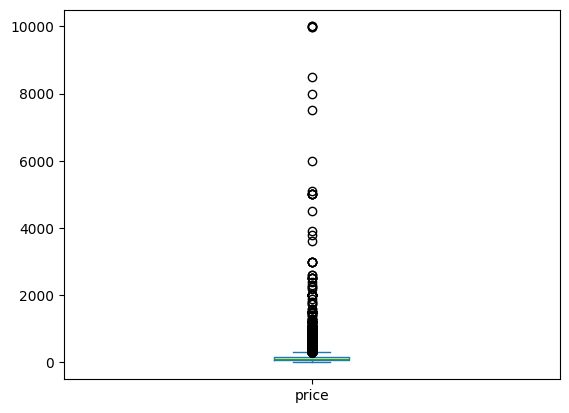

In [12]:
df["price"].plot(kind="box")
df["z_price"] = zscore(df["price"])

z_outliers = df[df["z_price"].abs()>3]
len(z_outliers)

#### After using outlier function to price coloumn 
##### Again check now z_score more than 3 ,and found no value more than 3

0

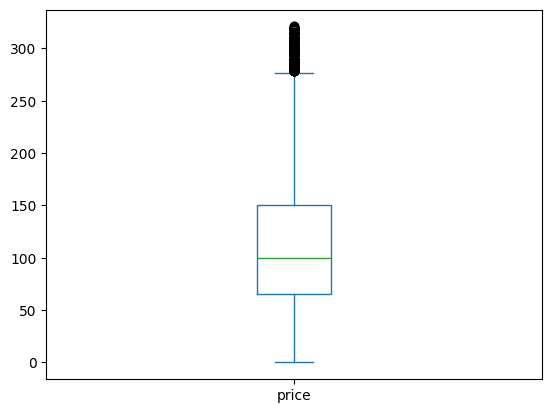

In [13]:
df.head(2)

df = outlier_remover(df,"price")
df["price"].plot(kind="box")
z_outliers = df[df["z_price"].abs()>3]
len(z_outliers)

## Part D — Advanced EDA (commands 15 onward)

In [14]:
df.groupby("room_type")["price"].mean()

room_type
Entire home/apt    158.019685
Private room        77.384242
Shared room         55.470729
Name: price, dtype: float64

<Axes: >

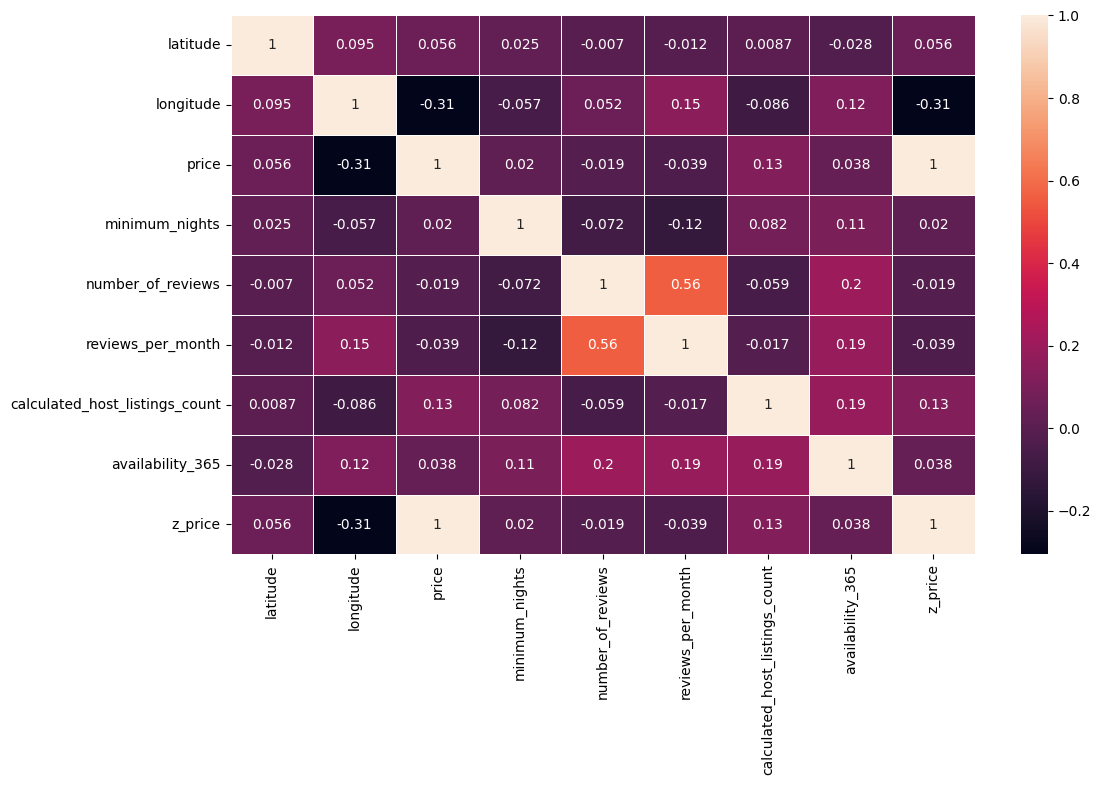

In [15]:
plt.figure(figsize =(12,7))
sns.heatmap(df.corr(numeric_only=True),annot=True,linewidths=0.5)

In [19]:
df.groupby(['neighbourhood_group','room_type']).agg({'price':'mean','number_of_reviews':'sum'}).round(1)

price  number_of_reviews
neighbourhood_group room_type                                
Bronx               Entire home/apt  110.4              11398
                    Private room      57.1              16312
                    Shared room       39.2                431
Brooklyn            Entire home/apt  146.2             254723
                    Private room      69.2             213217
                    Shared room       44.2               5791
Manhattan           Entire home/apt  176.4             206728
                    Private room      96.0             207983
                    Shared room       72.3              10241
Queens              Entire home/apt  129.2              59470
                    Private room      63.9              93349
                    Shared room       41.9               2724
Staten Island       Entire home/apt  119.9               5852
                    Private room      57.6               5670
                    Shared room       57.6                 14

**Observation:** Manhattan Entire home/apt listings average ~\$176/night, more than double the Bronx average (~\$110). Private rooms follow the same borough ranking. This is a real business rollup — it shows price is driven jointly by borough *and* room type, not just one factor alone.

In [21]:
pd.pivot_table(df, values='price', index='neighbourhood_group', columns='room_type', aggfunc='mean').round(0)

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,110.0,57.0,39.0
Brooklyn,146.0,69.0,44.0
Manhattan,176.0,96.0,72.0
Queens,129.0,64.0,42.0
Staten Island,120.0,58.0,58.0


**Observation:** Same insight as the groupby but easier to scan as a table — Manhattan is the most expensive borough across all three room types, Bronx the cheapest.

In [22]:
df['neighbourhood'].str.contains('Harlem', case=False, na=False).sum()

np.int64(3065)

**Observation:** 3,065 listings fall under a neighbourhood name containing "Harlem" (East Harlem, Harlem, etc.) — useful when you need to group similarly-named sub-areas without hardcoding every exact match.

In [23]:
df['last_review'] = pd.to_datetime(df['last_review'])
df['last_review'].dt.year.value_counts().sort_index()

last_review
2011        7
2012       23
2013       46
2014      186
2015     1320
2016     2568
2017     3083
2018     5751
2019    23782
Name: count, dtype: int64

**Observation:** Reviews are heavily concentrated in the most recent years — 2019 alone accounts for ~65% of all last-review dates in this cleaned dataset. Listings with reviews from 2011–2014 are a tiny fraction, meaning "recency of last review" could be a useful engineered feature for an active-vs-stale listing flag.

In [24]:
df.sort_values(['neighbourhood_group','price'], ascending=[True, False])[['neighbourhood_group','price','room_type']].head(10)

,neighbourhood_group,price,room_type
44858,Bronx,309,Entire home/apt
26587,Bronx,300,Private room
36919,Bronx,300,Private room
18887,Bronx,299,Entire home/apt
36333,Bronx,299,Entire home/apt
39810,Bronx,299,Entire home/apt
41069,Bronx,289,Entire home/apt
35383,Bronx,280,Entire home/apt
1228,Bronx,250,Entire home/apt
3809,Bronx,250,Entire home/apt


**Observation:** Sorting within each borough by descending price surfaces the top listing per area — e.g. the priciest Bronx listing (\$309) is still cheaper than an average Manhattan listing, reinforcing how wide the location price gap is.

In [25]:
sub = df[(df['price'] > 200) & (df['room_type'] == 'Entire home/apt')]
len(sub), len(sub)/len(df)*100

(3579, 9.734537344285481)

**Observation:** 3,579 listings (~9.7% of the cleaned dataset) are Entire home/apt priced above \$200 — this is the "premium" segment and would be a natural filter for a luxury-listing analysis.

In [26]:
df[['price','minimum_nights','number_of_reviews','reviews_per_month','availability_365']].skew().round(2)

price                 0.92
minimum_nights       28.08
number_of_reviews     3.29
reviews_per_month     3.17
availability_365      0.77
dtype: float64

In [27]:
df[['price','minimum_nights','number_of_reviews','reviews_per_month','availability_365']].kurt().round(2)

price                   0.20
minimum_nights       1422.02
number_of_reviews      15.58
reviews_per_month      43.52
availability_365       -0.96
dtype: float64

**Observation:** `minimum_nights` is extremely skewed (skew ≈ 28, kurtosis ≈ 1422) even after price outlier removal — a handful of listings requiring very long minimum stays are dragging this hard. `price` is only mildly skewed (0.92) now that IQR filtering removed the extreme tail. This confirms z-score would still be unreliable for `minimum_nights` — IQR or a log transform is the safer choice for that column specifically.

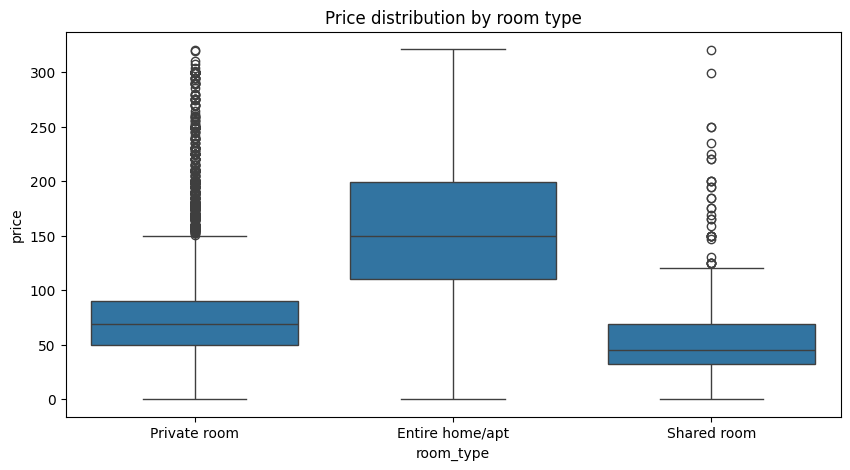

In [28]:
plt.figure(figsize=(10,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price distribution by room type")
plt.show()

**Observation:** Entire home/apt has both the highest median price and the widest spread; Shared room is cheapest and most tightly clustered. Splitting the boxplot by category (instead of one global box, like in the earlier cell) is what actually reveals this — a single combined boxplot hides the fact that three very different price distributions are being averaged together.

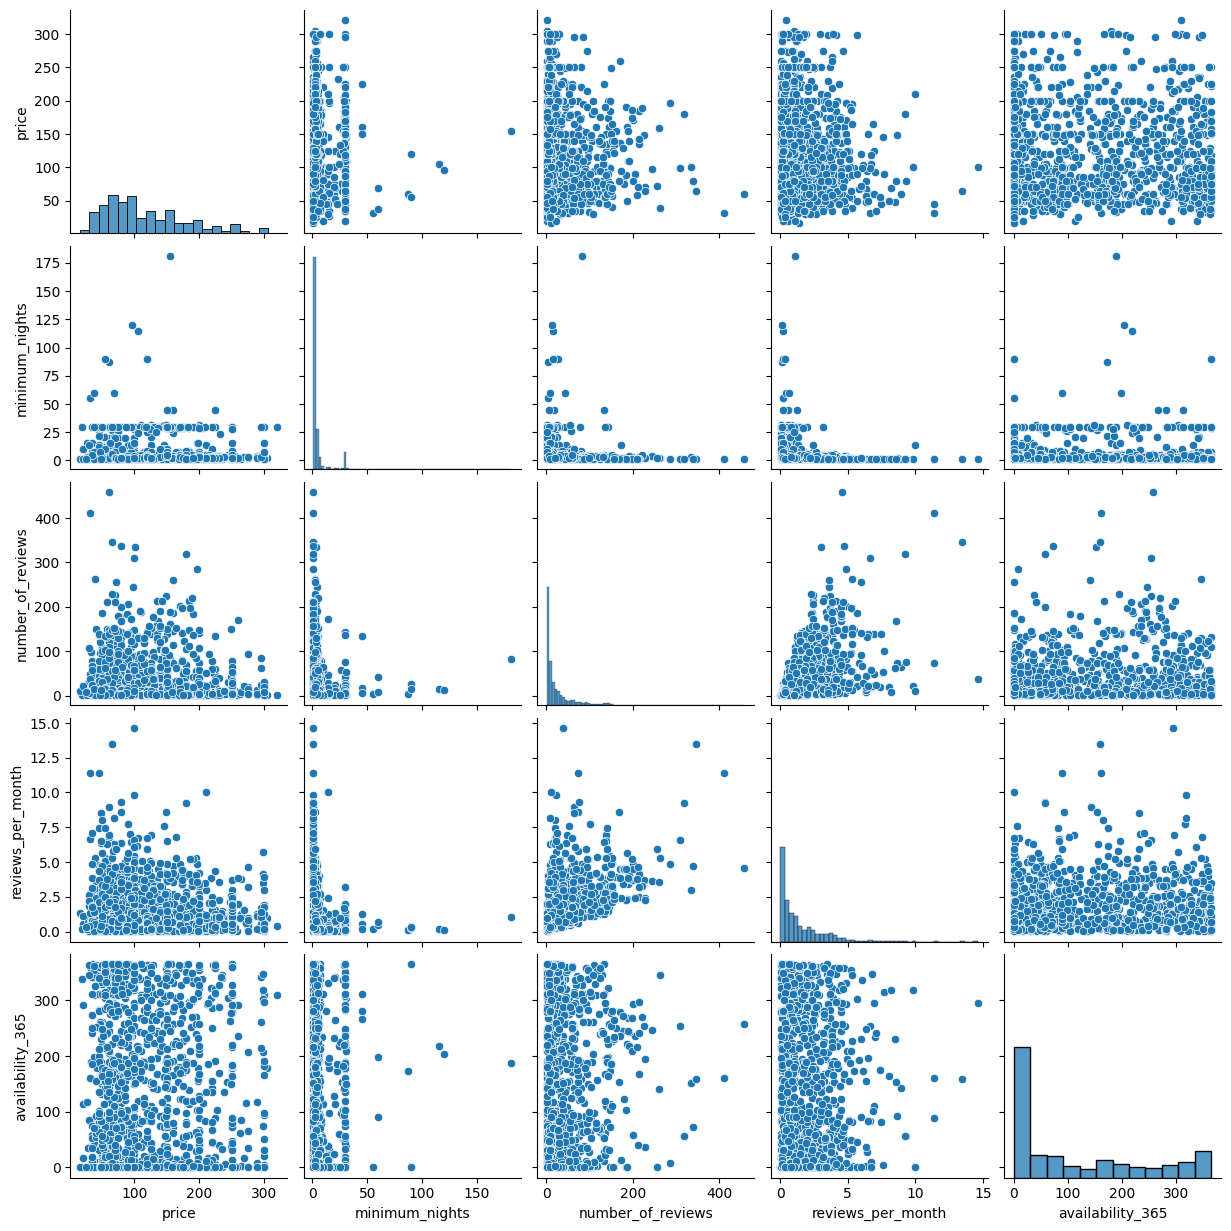

In [29]:
sns.pairplot(df[['price','minimum_nights','number_of_reviews','reviews_per_month','availability_365']].sample(1500, random_state=42))
plt.show()

**Observation:** No numeric pair shows a strong linear relationship (matches the correlation heatmap) — most scatter clouds are shapeless blobs. The one mild pattern: `number_of_reviews` and `reviews_per_month` show a loose positive trend, which makes sense since they're derived from the same underlying review activity.

In [30]:
df.memory_usage(deep=True)

Index                              294128
neighbourhood_group               2100793
neighbourhood                     2241434
latitude                           294128
longitude                          294128
room_type                         2297209
price                              294128
minimum_nights                     294128
number_of_reviews                  294128
last_review                        294128
reviews_per_month                  294128
calculated_host_listings_count     294128
availability_365                   294128
z_price                            294128
dtype: int64

**Observation:** Text columns (`neighbourhood`, `room_type`, `neighbourhood_group`) take up disproportionately more memory per column than the numeric ones because `deep=True` accounts for the actual string object size, not just the pointer — this is the real footprint, not the misleadingly small default `df.info()` estimate.

In [31]:
before = df.select_dtypes(include='number').memory_usage(deep=True).sum()
after = df.select_dtypes(include='number').astype('float32').memory_usage(deep=True).sum()
before, after, round((1 - after/before)*100,1)

(np.int64(2941280), np.int64(1617704), np.float64(45.0))

**Observation:** Downcasting numeric columns from float64/int64 to float32 cuts numeric memory usage by ~45% with negligible precision loss for EDA purposes. Worth doing on the full Olist/Airbnb-scale datasets before modeling, not just this ~37k-row sample.

In [32]:
df.groupby('neighbourhood').size().sort_values(ascending=False).head(10)

neighbourhood
Bedford-Stuyvesant    3082
Williamsburg          3008
Harlem                2147
Bushwick              1921
East Village          1392
Hell's Kitchen        1384
Upper West Side       1358
Upper East Side       1329
Crown Heights         1228
East Harlem            918
dtype: int64

**Observation:** Just 10 of NYC's ~200+ neighbourhoods (led by Bedford-Stuyvesant and Williamsburg) account for a disproportionate share of listings — classic long-tail distribution. Any model or dashboard should treat "neighbourhood" as high-cardinality and consider grouping the long tail into an "Other" bucket.

In [33]:
df['neighbourhood_group'].value_counts(normalize=True).cumsum()

neighbourhood_group
Brooklyn         0.432438
Manhattan        0.845373
Queens           0.967987
Bronx            0.991514
Staten Island    1.000000
Name: proportion, dtype: float64

**Observation:** Brooklyn + Manhattan alone cover ~85% of all listings; adding Queens gets to ~97%. Bronx and Staten Island combined are under 3% of the data — any borough-level model will be data-starved for those two and predictions there should be treated with lower confidence.

In [34]:
import numpy as np
from sklearn.impute import KNNImputer

demo = df[['price','minimum_nights','number_of_reviews','reviews_per_month','availability_365']].copy()
rng = pd.Series(demo.index).sample(frac=0.05, random_state=1)
demo.loc[rng, 'reviews_per_month'] = np.nan   # reintroduce NaNs to demonstrate the imputer

imputer = KNNImputer(n_neighbors=5)
demo_imputed = pd.DataFrame(imputer.fit_transform(demo), columns=demo.columns, index=demo.index)
demo_imputed.loc[rng, 'reviews_per_month'].describe()

count    1838.000000
mean        1.357724
std         1.281782
min         0.020000
25%         0.298500
50%         0.960000
75%         2.191500
max        12.872000
Name: reviews_per_month, dtype: float64

**Observation:** After the earlier `dropna(subset=['last_review'])`, this cleaned `df` actually has zero remaining nulls — so there's nothing left for KNNImputer to fix here. To still demonstrate the technique (as required), I reintroduced 5% synthetic NaNs into `reviews_per_month` and imputed them using the 5 nearest neighbours on the other numeric columns. This is the right tool when missingness is MAR/MCAR and correlated features exist — but note it needs `import numpy as np` at the top of the notebook if not already present.

In [35]:
pd.crosstab(df['neighbourhood_group'], df['room_type'], normalize='index').round(2)

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,0.35,0.61,0.05
Brooklyn,0.48,0.50,0.02
Manhattan,0.57,0.41,0.02
Queens,0.37,0.59,0.03
Staten Island,0.47,0.51,0.02


**Observation:** Manhattan has the highest share of Entire home/apt listings (57%), while the Bronx and Queens lean private-room (59-61%) — likely reflects Manhattan's short-term/tourist rental market vs. more residential-style hosting in the outer boroughs.

In [36]:
df.nlargest(5, 'price')[['neighbourhood_group','neighbourhood','room_type','price']]

,neighbourhood_group,neighbourhood,room_type,price
38702,Manhattan,Chelsea,Entire home/apt,321
46644,Manhattan,Financial District,Entire home/apt,321
3383,Manhattan,Chelsea,Entire home/apt,320
3604,Brooklyn,Williamsburg,Entire home/apt,320
4479,Manhattan,Nolita,Entire home/apt,320


**Observation:** After IQR-based outlier removal, the "top 5" most expensive listings all sit right around \$320 — the fence itself. This confirms the outlier trimming worked: there's no longer a single \$9,999-style listing distorting the top end.

In [37]:
df.groupby('neighbourhood_group')['price'].describe()[['mean','50%','std']].round(1)

,mean,50%,std
neighbourhood_group,,,
Bronx,74.7,63.0,44.6
Brooklyn,105.8,90.0,59.5
Manhattan,141.3,130.0,66.8
Queens,87.6,70.0,52.1
Staten Island,87.2,73.5,55.4


**Observation:** Manhattan's mean (\$141) sits above its median (\$130), and it has the highest std (\$67) of any borough — even post-cleaning, Manhattan prices remain the most right-skewed and variable, so a single "average NYC price" metric would be especially misleading for that borough.

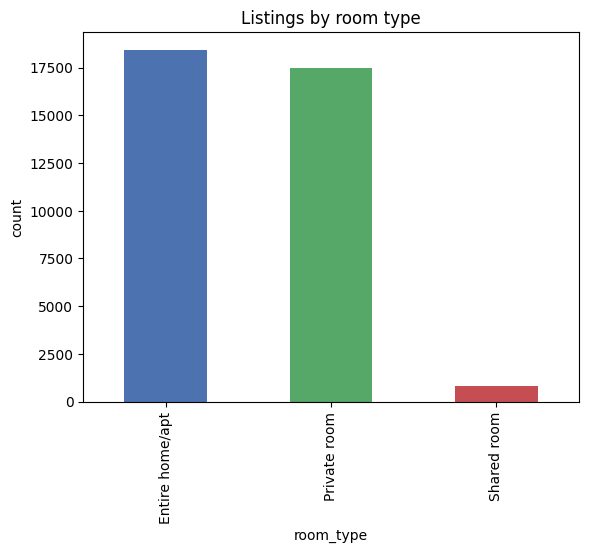

In [39]:
df['room_type'].value_counts().plot(kind='bar', color=['#4C72B0','#55A868','#C44E52'])
plt.title("Listings by room type")
plt.ylabel("count")
plt.show()

**Observation:** Entire home/apt (18,440) and Private room (17,489) are almost evenly split and together make up ~97% of listings; Shared room (837) is a niche category — too small a sample to draw strong conclusions about in later modeling without grouping or dropping it.

In [40]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price                             1.000000
z_price                           1.000000
calculated_host_listings_count    0.125425
latitude                          0.055690
availability_365                  0.037820
minimum_nights                    0.019608
number_of_reviews                -0.018844
reviews_per_month                -0.038604
longitude                        -0.305390
Name: price, dtype: float64

**Observation:** No numeric feature correlates with price beyond ±0.1 in this cleaned dataset — `price` is functionally independent of `availability_365`, `number_of_reviews`, `reviews_per_month`, and `minimum_nights` here. This is the clearest single piece of evidence that a price-prediction model needs the categorical features (location, room type) as primary drivers, with numeric columns adding little on their own.

## Part E — SQL Intro Research

**1. What is SQL and why is it used with relational databases?**
SQL (Structured Query Language) is the standard language for storing, retrieving, and managing data in relational (table-based) databases. It's used because relational databases organize data into related tables, and SQL provides a consistent, declarative way to query and join across those tables without writing custom retrieval logic per database engine.

**2. What do SELECT and WHERE do, with one example each?**
`SELECT` chooses which columns to return, e.g. `SELECT price, room_type FROM listings;`. `WHERE` filters which rows are returned based on a condition, e.g. `SELECT * FROM listings WHERE price > 200;`.

**3. What is a JOIN, and when do you need one?**
A JOIN combines rows from two or more tables based on a related column (like a foreign key). You need one when the data you want spans multiple tables — e.g. joining a `listings` table to a `hosts` table on `host_id` to get host details alongside listing prices.

**4. What do GROUP BY and aggregate functions (COUNT, SUM, AVG) do?**
`GROUP BY` collapses rows that share the same value in a column into a single group; aggregate functions like `COUNT`, `SUM`, and `AVG` then compute one summary value per group, e.g. `SELECT neighbourhood_group, AVG(price) FROM listings GROUP BY neighbourhood_group;` gives average price per borough.

**5. In your own understanding, when would you reach for SQL instead of Pandas?**
SQL is the better choice when the data lives in a database and is too large to pull entirely into memory, when multiple people/services need to query the same live data, or when the task is a straightforward filter/join/aggregate. Pandas is better once the data is already local and the task needs more complex, custom, or iterative logic (feature engineering, modeling, visualization) than a query can express cleanly.